# COVID-19 FAQ retrieval — development notebook

How the retriever in this repository was built and measured: the corpus, the
lexical baseline, the semantic retriever that replaces it, the abstention
threshold, and the final held-out result.

**Reusable logic lives in `src/`.** This notebook imports it and orchestrates;
`src/api.py` imports the same modules, so the numbers below are the numbers the
deployed service produces.

| Section | |
|---|---|
| 1 | Setup |
| 2 | Building the knowledge base |
| 3 | Corpus |
| 4 | Queries and relevance judgments |
| 5 | Split integrity |
| 6 | BM25 baseline |
| 7 | Semantic retriever and abstention |
| 8 | Final result |

Every reported figure comes from the held-out **test** split via
`src/evaluate.py`, with a confidence interval wherever a comparison is claimed.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Everything analytical is imported, never redefined here.
from src import prep
from src.evaluate import (
    DATA_DIR,
    OFF_TOPIC_PROBE,
    evaluate,
    format_table,
    load_eval_data,
    paired_bootstrap,
    select_split,
    summarize_abstention,
    tune_threshold,
)
from src.index import ARTIFACTS_DIR, load_or_build_index
from src.retriever import BM25Retriever, BiEncoderRetriever, load_kb

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110

print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\Documents\COVID-19-CHAT-BOT


## 2. Building the knowledge base

`src.prep` turns raw COUGH into the served corpus. It is deterministic: same
inputs and seed, byte-identical outputs.

In [2]:
if not (DATA_DIR / "kb.parquet").exists():
    from src import download

    download.fetch()
    prep.run()

kb = load_kb()
eval_queries, relevant_by_query = load_eval_data()
report = json.loads((DATA_DIR / "prep_report.json").read_text(encoding="utf-8"))

print(f"KB      {len(kb):>7,} entries")
print(f"queries {len(eval_queries):>7,}")
print(f"qrels   {int(sum(len(v) for v in relevant_by_query.values())):>7,} positives")

KB        7,077 entries
queries   1,201
qrels     7,833 positives


### What preprocessing changed

Two numbers matter here.

**`qrels_remapped`** — judgments pointing at a de-duplicated FAQ row, redirected
onto the surviving copy rather than dropped. Discarding them would delete real
positives and understate every metric that follows.

**The positive accounting** — `src.prep` asserts `raw == final + lost + merged`
and refuses to write artifacts if it doesn't balance.

In [3]:
pd.DataFrame(
    [
        ("raw FAQ rows",                report["raw_faq_rows"]),
        ("dropped: unusable",           len(report["dropped_missing_question"])
                                        + len(report["dropped_missing_answer"])),
        ("duplicate groups collapsed",  report["duplicate_groups"]),
        ("KB rows",                     report["kb_rows"]),
        ("",                            None),
        ("raw qrel rows",               report["raw_qrel_rows"]),
        ("dropped: orphan query",       report["qrels_dropped_orphan_query"]),
        ("REMAPPED onto surviving dup", report["qrels_remapped"]),
        ("  of which positive",         report["qrels_remapped_positive"]),
        ("",                            None),
        ("raw positives",               report["raw_positive_rows"]),
        ("  lost",                      report["positives_lost"]),
        ("  merged",                    report["positives_merged"]),
        ("  final",                     report["positive_rows"]),
    ],
    columns=["step", "n"],
).fillna("").style.hide(axis="index")

step,n
raw FAQ rows,7117.000000
dropped: unusable,2.000000
duplicate groups collapsed,36.000000
KB rows,7077.000000
,
raw qrel rows,39760.000000
dropped: orphan query,1145.000000
REMAPPED onto surviving dup,241.000000
of which positive,64.000000
,


In [4]:
balanced = report["positive_rows"] + report["positives_lost"] + report["positives_merged"]
print(f'{report["raw_positive_rows"]:,} raw positives = {report["positive_rows"]:,} final '
      f'+ {report["positives_lost"]:,} lost + {report["positives_merged"]:,} merged')
assert balanced == report["raw_positive_rows"]
print("accounting balances")

7,856 raw positives = 7,833 final + 1 lost + 22 merged
accounting balances


## 3. Corpus

The knowledge base is both the retrieval corpus and the served content, so its
weaknesses are the product's weaknesses.

trust
official     3986
community    3091

official: 56.3% of the corpus


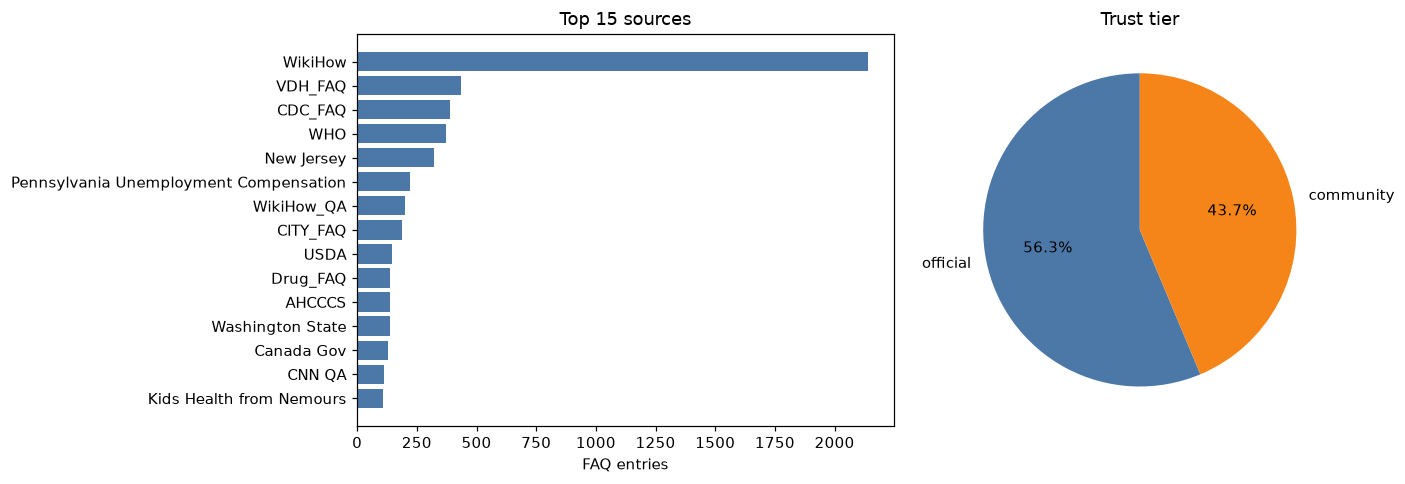

In [5]:
trust = kb["trust"].value_counts()
print(trust.to_string())
print(f"\nofficial: {trust.get('official', 0) / len(kb):.1%} of the corpus")

top = kb["source"].value_counts().head(15)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].barh(top.index[::-1], top.values[::-1], color="#4C78A8")
ax[0].set_title("Top 15 sources")
ax[0].set_xlabel("FAQ entries")
ax[1].pie(trust.values, labels=trust.index, autopct="%1.1f%%",
          colors=["#4C78A8", "#F58518"], startangle=90)
ax[1].set_title("Trust tier")
plt.tight_layout()
plt.show()

WikiHow alone is ~30% of the corpus and community sources are a large minority.
That drives three product decisions: responses carry a `trust` field so the UI
can label provenance, the disclaimer is unconditional rather than reserved for
community answers, and when duplicates are collapsed the **official** copy
survives — so identical content is attributed to the better source.

A third `academic` tier (Harvard, JHU, AMA) is defensible; this build keeps two.

,count,mean,std,min,25%,50%,75%,max
question_words,7077.0,13.0,9.2,1.0,8.0,11.0,15.0,273.0
answer_words,7077.0,113.5,121.8,1.0,55.0,86.0,128.0,2960.0


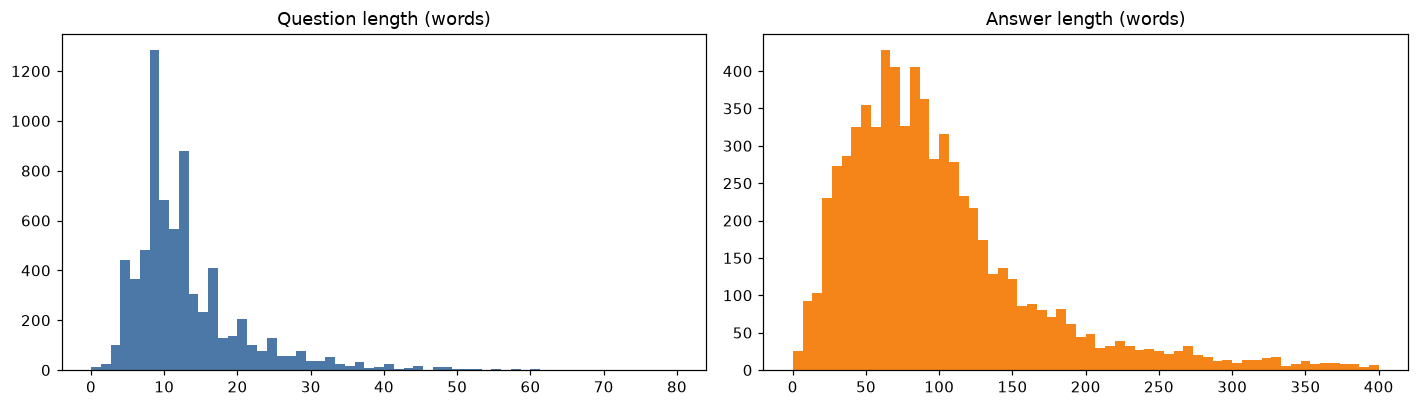

In [6]:
lengths = pd.DataFrame({
    "question_words": kb["question"].str.split().str.len(),
    "answer_words": kb["answer"].str.split().str.len(),
})
display(lengths.describe().T.round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].hist(lengths["question_words"], bins=60, range=(0, 80), color="#4C78A8")
ax[0].set_title("Question length (words)")
ax[1].hist(lengths["answer_words"], bins=60, range=(0, 400), color="#F58518")
ax[1].set_title("Answer length (words)")
plt.tight_layout()
plt.show()

Answers are long and heavily right-skewed; questions are short. This is why the
index is built on the **question field alone** — long answers dilute the lexical
signal, and a user query resembles a question rather than a document. §6 measures
that rather than assuming it.

In [7]:
# Numbers and units are content, not noise: the previous pipeline stripped every
# digit, turning "20 seconds" into "seconds".
mask = kb["answer"].str.contains(r"\b(?:20 seconds|6 feet|14 days|2 metres)\b",
                                 case=False, regex=True)
print(f"{int(mask.sum()):,} answers contain a load-bearing quantity\n")
for text in kb.loc[mask, "answer"].head(2):
    print(" -", text[:140], "...")

547 answers contain a load-bearing quantity

 - Most people will have mild effects from the virus, but it can cause severe illness and pneumonia in others. Symptoms may appear 2-14 days af ...
 - COVID-19 illness is spread mainly from person to person through respiratory droplets (mucous from the nose and throat) when a person who has ...


## 4. Queries and relevance judgments

sample queries:
 - How is COVID-19 spread in public places?
 - When coronavirus is referred to as a global pandemic, what kind of meaning does that actually have?
 - How to distinguish between quarantine, isolation, and distancing of oneself?
 - What age groups are the most at-risk?
 - What should I do in terms of already scheduled medical appointments for my child, keep them or cancel them?

queries                1,201
positives per query    mean 6.52, range 1-25


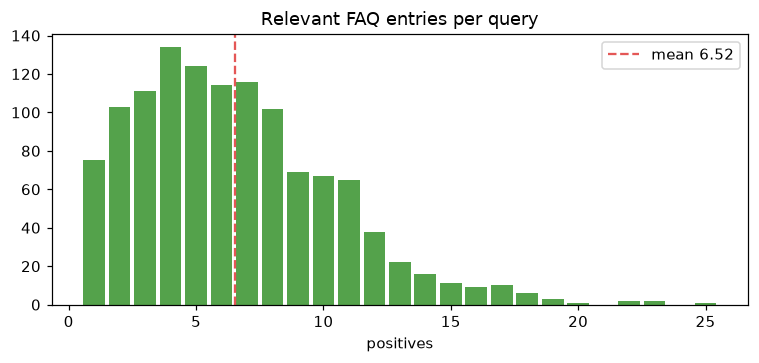

In [8]:
pos_per_query = pd.Series({q: len(v) for q, v in relevant_by_query.items()})

print("sample queries:")
for q in eval_queries["query"].head(5):
    print(" -", q)
print(f"\nqueries                {len(eval_queries):,}")
print(f"positives per query    mean {pos_per_query.mean():.2f}, "
      f"range {pos_per_query.min()}-{pos_per_query.max()}")

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.hist(pos_per_query, bins=range(1, pos_per_query.max() + 2), color="#54A24B",
        align="left", rwidth=0.85)
ax.axvline(pos_per_query.mean(), color="#E45756", ls="--",
           label=f"mean {pos_per_query.mean():.2f}")
ax.set_title("Relevant FAQ entries per query")
ax.set_xlabel("positives")
ax.legend()
plt.tight_layout()
plt.show()

**Why MRR@10 and P@1 lead.** Queries average ~6.5 relevant entries, so Recall@10
is capped by annotation density rather than retrieval quality — a perfect
retriever showing ten results cannot recall twenty-five positives. Reporting
recall as the headline would measure the annotation, not the system.

MRR@10 and P@1 answer the question the product actually poses: *is the top result
right?* The chat UI shows exactly one answer.

## 5. Split integrity

The **corpus is never split**. The 1,201 queries are partitioned; all 7,077 KB
entries stay retrievable for every query in every split.

In [9]:
split_files = {
    name: json.loads((DATA_DIR / "splits" / f"{name}.json").read_text(encoding="utf-8"))
    for name in ("train", "dev", "test")
}
sizes = {k: v["n"] for k, v in split_files.items()}
total = sum(sizes.values())
print(f"seed: {split_files['train']['seed']}\n")
for name, n in sizes.items():
    print(f"  {name:<6} {n:>5,}  {n / total:6.1%}")

ids = {k: set(v["query_ids"]) for k, v in split_files.items()}
assert ids["train"] | ids["dev"] | ids["test"] == set(eval_queries["query_id"])
assert not (ids["train"] & ids["dev"] or ids["train"] & ids["test"] or ids["dev"] & ids["test"])

# Reproducible from the seed alone, or "evaluate on test only" is unverifiable.
rebuilt = prep.make_splits(sorted(eval_queries["query_id"]), seed=split_files["train"]["seed"])
assert all(rebuilt[name] == split_files[name]["query_ids"] for name in rebuilt)

print("\npartition exact and disjoint; regenerates from the seed")
print(f"corpus available to every split: {len(kb):,} entries")

seed: 42

  train    840   69.9%
  dev      180   15.0%
  test     181   15.1%

partition exact and disjoint; regenerates from the seed
corpus available to every split: 7,077 entries


## 6. BM25 baseline

The lexical baseline the semantic retriever has to beat. It trains on nothing,
so the same index serves every split and there is no leakage to reason about.

In [10]:
retrievers = {f: BM25Retriever(kb, field=f) for f in ("question", "question_answer")}
all_results = [
    evaluate(r, eval_queries, relevant_by_query, split="all", corpus_size=len(kb))
    for r in retrievers.values()
]
print(format_table(all_results))

retriever                split      n     MRR@10        P@1        P@3        P@5  Recall@10    nDCG@10
-------------------------------------------------------------------------------------------------------
bm25[question]           all     1201     0.5240     0.4213     0.2659     0.2097     0.2501     0.2759
bm25[question_answer]    all     1201     0.4619     0.3439     0.2434     0.1990     0.2572     0.2644


### 6.1 Cross-checking the harness

The published COUGH baseline is MRR@10 0.530 / P@1 0.421 over all 1,201 queries. Re-deriving it is how we know the evaluation code is correct
rather than merely self-consistent.

In [11]:
PUBLISHED = {
    "bm25[question]":        {"MRR@10": 0.530, "P@1": 0.421, "P@3": 0.267, "P@5": 0.211},
    "bm25[question_answer]": {"MRR@10": 0.469, "P@1": 0.344, "P@3": 0.244, "P@5": 0.199},
}
rows = [
    {"retriever": r.retriever, "metric": m, "published": PUBLISHED[r.retriever][m],
     "measured": round(v, 4), "delta": round(v - PUBLISHED[r.retriever][m], 4)}
    for r in all_results
    for m, v in r.headline().items()
    if m in PUBLISHED[r.retriever]
]
comparison = pd.DataFrame(rows)
display(comparison)
print(f"largest absolute deviation: {comparison['delta'].abs().max():.4f}")

,retriever,metric,published,measured,delta
0,bm25[question],MRR@10,0.530,0.5240,-0.0060
1,bm25[question],P@1,0.421,0.4213,0.0003
2,bm25[question],P@3,0.267,0.2659,-0.0011
3,bm25[question],P@5,0.211,0.2097,-0.0013
4,bm25[question_answer],MRR@10,0.469,0.4619,-0.0071
5,bm25[question_answer],P@1,0.344,0.3439,-0.0001
6,bm25[question_answer],P@3,0.244,0.2434,-0.0006
7,bm25[question_answer],P@5,0.199,0.1990,0.0000


largest absolute deviation: 0.0071


Largest deviation across all eight figures is **0.0071**, and P@1 — which has no
rank-averaging to blur it — lands within 0.0003 on both fields.

The small negative bias on MRR@10 is expected: these run on the **deduplicated**
corpus (7,077 entries, 22 positives merged), while the published figures used the
raw 7,117-row bank. Collapsing two identical entries removes one of the two
chances a query had to hit inside the top ten.

The qualitative finding reproduces too: **question-only beats question+answer** on
every precision metric, so question-only is the indexed field. Recall@10 runs the
other way (0.250 vs 0.257) — answer text finds slightly more relevant documents
but ranks them worse, and ranking is what a one-answer UI needs.

### 6.2 Per split

In [12]:
bm25 = retrievers["question"]
split_results = [
    evaluate(bm25, select_split(eval_queries, s), relevant_by_query, split=s, corpus_size=len(kb))
    for s in ("train", "dev", "test", "all")
]
split_table = pd.DataFrame([r.to_row() for r in split_results]).set_index("split")
display(split_table.drop(columns=["retriever"]))

spread = split_table.loc[["train", "dev", "test"], "MRR@10"]
print(f"MRR@10 spread across splits: {spread.min():.4f}-{spread.max():.4f} "
      f"(range {spread.max() - spread.min():.4f})")

,n,MRR@10,P@1,P@3,P@5,Recall@10,nDCG@10
split,,,,,,,
train,840,0.5248,0.4214,0.2679,0.2119,0.2512,0.2775
dev,180,0.5315,0.4389,0.2611,0.2078,0.2549,0.2773
test,181,0.5127,0.4033,0.2615,0.2011,0.2401,0.2670
all,1201,0.5240,0.4213,0.2659,0.2097,0.2501,0.2759


MRR@10 spread across splits: 0.5127-0.5315 (range 0.0188)


The three splits span 0.019 MRR@10, so the seed did not produce a lopsided
partition, and test sits marginally below the others rather than being flattered.

Test is **181 queries**. One query moving from rank 2 to rank 1 shifts MRR@10 by
about 0.003, so the resolution limit is roughly ±0.03 — differences smaller than
that are not evidence.

### 6.3 Where BM25 fails

In [13]:
test_queries = select_split(eval_queries, "test")
test_detail = evaluate(bm25, test_queries, relevant_by_query, split="test",
                       corpus_size=len(kb), keep_per_query=True)
detail = pd.DataFrame(test_detail.per_query)

missed = detail[detail["rr"] == 0.0]
print(f"{len(missed)} of {len(detail)} test queries ({len(missed) / len(detail):.0%}) "
      f"found nothing relevant in the top 10\n")

kb_by_id = kb.set_index("id")
lookup = dict(zip(eval_queries["query_id"], eval_queries["query"], strict=True))
from src.retriever import tokenize

for row in missed.head(2).itertuples():
    gold = list(relevant_by_query[row.query_id])[0]
    q_tokens = set(tokenize(lookup[row.query_id]))
    g_tokens = set(tokenize(kb_by_id.loc[gold, "question"]))
    print(f"QUERY   {lookup[row.query_id]}")
    print(f"GOLD    {kb_by_id.loc[gold, 'question'][:90]}")
    print(f"        shared tokens: {sorted(q_tokens & g_tokens)}\n")

48 of 181 test queries (27%) found nothing relevant in the top 10

QUERY   What assurances do we have that face coverings keep out the virus?
GOLD    How do cloth face coverings work to prevent spread of COVID-19?
        shared tokens: ['coverings', 'do', 'face']

QUERY   Suggestions on how to stay in touch while not risking to get infected?
GOLD    I have a chronic medical condition that puts me at increased risk for severe illness from 
        shared tokens: ['in', 'to']



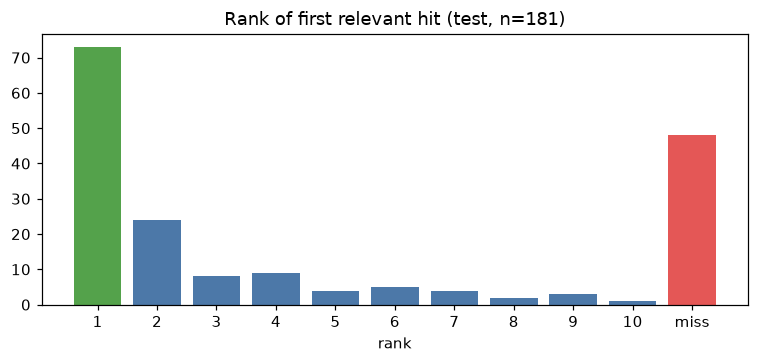

rank 1: 73   ranks 2-10: 60   missed: 48


In [14]:
ranks = detail["rr"].apply(lambda x: round(1 / x) if x > 0 else 11)
counts = ranks.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(counts.index, counts.values,
       color=["#54A24B" if i == 1 else "#4C78A8" if i <= 10 else "#E45756" for i in counts.index])
ax.set_xticks(range(1, 12))
ax.set_xticklabels([*map(str, range(1, 11)), "miss"])
ax.set_title("Rank of first relevant hit (test, n=181)")
ax.set_xlabel("rank")
plt.tight_layout()
plt.show()

print(f"rank 1: {(ranks == 1).sum()}   ranks 2-10: {((ranks > 1) & (ranks <= 10)).sum()}"
      f"   missed: {(ranks == 11).sum()}")

The distribution is **bimodal** — BM25 either answers at rank 1 or misses
entirely, with a thin middle. That splits the remaining headroom into two
problems with different solutions:

| Outcome | Queries | Fixable by |
|---|---|---|
| Hit at rank 1 | 73 (40%) | — |
| Hit at ranks 2–10 | 60 (33%) | re-ranking the candidates |
| Nothing relevant retrieved | 48 (27%) | retrieving on meaning |

The 27% are a recall problem: one failing query shares **zero** tokens with its
gold entry, so no amount of term weighting reaches it. A re-ranker only reorders
what it is given, which is why a dense retriever comes first.

## 7. Semantic retriever

A bi-encoder embeds query and FAQ entry separately and compares them by cosine
similarity, so it can match on meaning — which is what the 27% need.

Two candidates, both pre-trained and used as-is.

In [15]:
DENSE_MODELS = ["sentence-transformers/all-MiniLM-L6-v2", "BAAI/bge-base-en-v1.5"]

dense = {}
for name in DENSE_MODELS:
    index = load_or_build_index(kb, model_name=name, field="question")
    dense[name] = BiEncoderRetriever(index)
    print(f"{name:<42} {index.embeddings.shape[1]} dims")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

sentence-transformers/all-MiniLM-L6-v2     384 dims


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BAAI/bge-base-en-v1.5                      768 dims


In [16]:
dense_results = [
    evaluate(r, test_queries, relevant_by_query, split="test", corpus_size=len(kb),
             keep_per_query=True)
    for r in dense.values()
]
# Reuses the per-query detail computed in 6.3, which the bootstrap in 8 needs.
bm25_test = test_detail

print(format_table([bm25_test, *dense_results]))

retriever                split      n     MRR@10        P@1        P@3        P@5  Recall@10    nDCG@10
-------------------------------------------------------------------------------------------------------
bm25[question]           test     181     0.5127     0.4033     0.2615     0.2011     0.2401     0.2670
biencoder[all-MiniLM-L6-v2] test     181     0.6128     0.4972     0.3352     0.2641     0.3432     0.3570
biencoder[bge-base-en-v1.5] test     181     0.6294     0.5304     0.3425     0.2751     0.3613     0.3769


Both encoders beat BM25 on MRR@10 and P@1, well clear of the ±0.03 resolution
limit. bge-base ranks slightly higher than MiniLM (+0.017 MRR@10) — but ranking
is not the only thing that matters, as the threshold below shows.

### 7.1 Abstention

The product must decline when nothing matches. COUGH cannot validate
this directly: **every** query in it has at least one positive, so the benchmark
contains no unanswerable questions and tuning τ for F1 on it degenerates to
"never abstain".

So τ is tuned against a 12-query hand-written out-of-scope probe
(`src.evaluate.OFF_TOPIC_PROBE`) — a smoke test, not a benchmark, and labelled as
such. It is the honest gap in this evaluation.

In [17]:
dev_queries = select_split(eval_queries, "dev")
choices = {}

for name, retriever in dense.items():
    hits = retriever.search_batch(list(dev_queries["query"]), top_k=1)
    in_scope = [h[0][1] if h else 0.0 for h in hits]
    correct = [
        bool(h) and h[0][0] in relevant_by_query.get(int(qid), set())
        for h, qid in zip(hits, dev_queries["query_id"], strict=True)
    ]
    off = [h[0][1] if h else 0.0 for h in retriever.search_batch(list(OFF_TOPIC_PROBE), top_k=1)]

    choice = tune_threshold(in_scope, correct, objective="off_topic", off_topic_scores=off)
    summary = summarize_abstention(choice.tau, in_scope,
                                   list(zip(OFF_TOPIC_PROBE, off, strict=True)))
    choices[name] = (choice, summary, in_scope, off)

    print(f"{name.split('/')[-1]:<24} tau {choice.tau:.4f}   "
          f"in-scope answered {summary.in_scope_answered:.0%}   "
          f"off-topic answered {summary.off_topic_answered:.0%}")

all-MiniLM-L6-v2         tau 0.6932   in-scope answered 77%   off-topic answered 0%

bge-base-en-v1.5         tau 0.7816   in-scope answered 58%   off-topic answered 0%


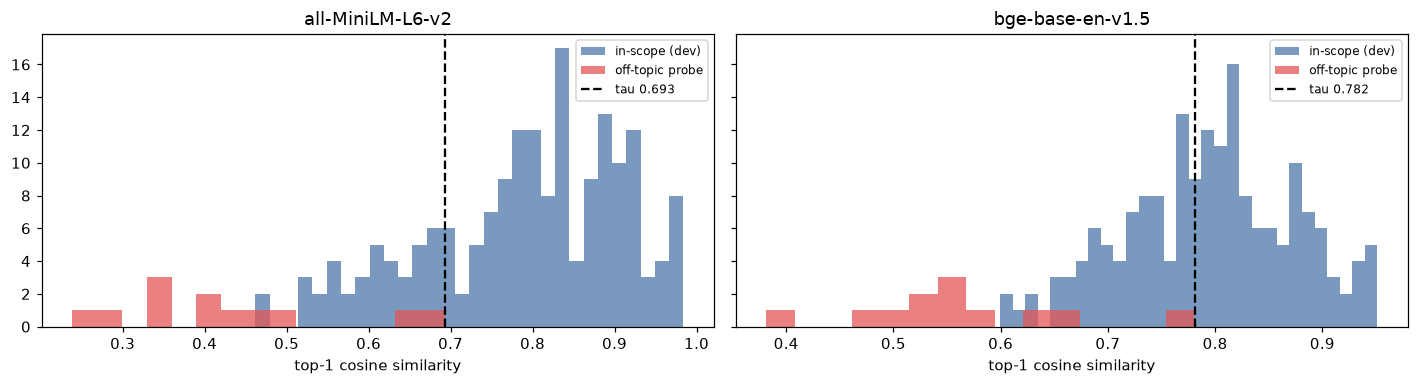

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), sharey=True)
for ax, (name, (choice, _, in_scope, off)) in zip(axes, choices.items(), strict=True):
    ax.hist(in_scope, bins=30, alpha=0.75, label="in-scope (dev)", color="#4C78A8")
    ax.hist(off, bins=15, alpha=0.75, label="off-topic probe", color="#E45756")
    ax.axvline(choice.tau, color="black", ls="--", label=f"tau {choice.tau:.3f}")
    ax.set_title(name.split("/")[-1])
    ax.set_xlabel("top-1 cosine similarity")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**The better ranker is the worse abstainer.** bge-base's off-topic queries score
0.561 on average against MiniLM's 0.421, so its two distributions sit closer
together and τ must be pushed higher — costing 19 points of in-scope coverage to
buy the same off-topic rejection.

Cosine similarity is calibrated differently per model; a good ranker is not
automatically a good confidence estimator.

**MiniLM is therefore the encoder we ship.** It gives up 0.017 MRR@10 and buys
back 19 points of answered queries at equal rejection — the right trade for a bot
whose worst failure is a confident wrong answer — and it is 5× smaller,
which keeps the deployed image small.

In [19]:
config = json.loads((ARTIFACTS_DIR / "retriever_config.json").read_text(encoding="utf-8"))
print(json.dumps(config, indent=2))

{
  "encoder": "sentence-transformers/all-MiniLM-L6-v2",
  "field": "question",
  "tau": 0.6932,
  "tuned_on": "dev",
  "objective": "off_topic",
  "dev_in_scope_answered": 0.7667,
  "probe_off_topic_answered": 0.0,
  "probe_size": 12,
  "note": "tau rejects the whole off-topic probe while keeping as much in-scope coverage as possible. The probe is 12 hand-written queries, not a benchmark -- see src.evaluate.OFF_TOPIC_PROBE."
}


`src/api.py` loads that file at startup. It is the whole served configuration:
which encoder, which field, which threshold.

## 8. Final result

Measured on the 181 held-out test queries against the full 7,077-entry corpus.
Reproducible with `python -m src.evaluate --split test --retriever both`.

In [20]:
SHIPPED = "sentence-transformers/all-MiniLM-L6-v2"
shipped_result = next(r for r in dense_results if SHIPPED.split("/")[-1] in r.retriever)

summary = pd.DataFrame([bm25_test.to_row(), shipped_result.to_row()])
summary.insert(0, "system", ["BM25 (baseline)", "MiniLM bi-encoder  <- SHIPPED"])
display(summary.drop(columns=["retriever", "split"]).set_index("system"))

# A delta on 181 queries is not evidence on its own.
for metric, name in [("rr", "MRR@10"), ("p_at_1", "P@1")]:
    c = paired_bootstrap(bm25_test, shipped_result, metric=metric)
    print(f"{name:<7} {c.delta:+.4f}   95% CI [{c.ci_low:+.4f}, {c.ci_high:+.4f}]   "
          f"p={c.p_value:.4f}   {'SIGNIFICANT' if c.significant else 'not significant'}")

,n,MRR@10,P@1,P@3,P@5,Recall@10,nDCG@10
system,,,,,,,
BM25 (baseline),181,0.5127,0.4033,0.2615,0.2011,0.2401,0.267
MiniLM bi-encoder <- SHIPPED,181,0.6128,0.4972,0.3352,0.2641,0.3432,0.357


MRR@10  +0.1001   95% CI [+0.0444, +0.1566]   p=0.0004   SIGNIFICANT
P@1     +0.0939   95% CI [+0.0276, +0.1602]   p=0.0072   SIGNIFICANT


Both intervals sit clear of zero.

The largest movement is **Recall@10, 0.240 → 0.343 (+43%)**, which is the point:
§6.3 showed BM25's failures were dominated by queries where nothing relevant was
retrieved at all. Semantic matching reaches exactly those.

### Shipped system

```
query ─► MiniLM-L6-v2 ─► cosine over 7,077 KB questions
                           │
           score ≥ τ 0.693 ┴─ score < τ
                 │              │
     stored answer + source   abstention
     + trust tier + disclaimer + WHO/CDC pointer
```

| | test (n=181) |
|---|---|
| MRR@10 | **0.6128** |
| P@1 | **0.4972** |
| Recall@10 | 0.3432 |
| nDCG@10 | 0.3570 |
| vs BM25 | +0.100 MRR@10, 95% CI [+0.044, +0.157], p = 0.0004 |
| abstention | answers 77% of in-scope, 0% of the off-topic probe |

### Known limits

- The corpus is a 2020–2021 snapshot; guidance on variants and vaccines has moved on.
- ~44% of it is community content, which is why every answer carries a trust tier.
- Abstention is tuned against a 12-query probe, not a labelled unanswerable set.
- 181 test queries resolve differences of roughly ±0.03 MRR@10, no finer.